# EDA, Limpieza y distribución de los datos 

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("/datasets/everpeak_retail.csv")
df_copy = df.copy()

print("--- Información General del Dataset ---")
print(df_copy.info())

print("\n--- Resumen Estadístico de Columnas Numéricas ---")
print(df_copy.describe())

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB
None

--- Resumen Estadístico de Columnas Numéricas ---
          order_id  customer_id         price     quantity    order_value  \
count  5008.000000  5008.000000   5008.000000

In [43]:
## Error en la captuta de la columna 'quantity' (se mitiga con el pipe line de limpieza, relacionado con fechas erroneas)
print("Total de filas con 0 en 'quantity':", (df_copy['quantity']== 0).sum())

Total de filas con 0 en 'quantity': 2971


In [19]:
# Análisis Exploratorio (EDA) y Diagnóstico
#Conteo inicial de ausencias
print("--- Conteo de Valores Faltantes por Columna ---")
print(df_copy.isna().sum())

# Validación de hipótesis de ausencia (Análisis de Datos Faltantes)
print("\n--- Relación de ausencias en 'city' según el método de pago (MCAR) ---")
missing_city_by_pay = (
    df_copy["city"].isna().groupby(df_copy["payment_method"]).mean() * 100
).sort_values(ascending=False)
print(missing_city_by_pay)

# Diagnóstico de Valores Atípicos / Sentinela en Edad
edades_sospechosas = df_copy[
    (df_copy["customer_age"] < 12) | (df_copy["customer_age"] > 100)
]
print("\n--- Diagnóstico de Valores Atípicos en 'customer_age' ---")
print(f"Total de registros fuera de rango común: {len(edades_sospechosas)}")
print(edades_sospechosas["customer_age"].value_counts())

--- Conteo de Valores Faltantes por Columna ---
order_id              0
order_date            8
customer_id           0
product_category      0
price                 0
quantity              0
order_value           0
payment_method        0
city                100
state               100
customer_age        150
dtype: int64

--- Relación de ausencias en 'city' según el método de pago (MCAR) ---
payment_method
credit_card    2.151714
debit_card     2.130045
cash           2.010050
paypal         1.531915
Name: city, dtype: float64

--- Diagnóstico de Valores Atípicos en 'customer_age' ---
Total de registros fuera de rango común: 25
-999.0    25
Name: customer_age, dtype: int64


In [20]:
def pipeline_limpieza_everpeak(df, median_fill_cols, fill_unknown_cols, date_drop_cols):
    """Pipeline profesional para la limpieza e imputación de datos.

    - Remueve valores centinela e imputa numéricos con la mediana.
    - Rellena categorías vacías con un identificador 'unknown'.
    - Transforma fechas y elimina registros inválidos.
    """
    df_local = df.copy()

    # Tratamiento de columnas numéricas y eliminación de valores basura
    for col in median_fill_cols:
        valores_basura = [-999, 999, 0, 1]
        df_local[col] = df_local[col].replace(valores_basura, np.nan)
        df_local[col] = pd.to_numeric(df_local[col], errors="coerce")

        # Cálculo la mediana limpia sin el sesgo de los valores basura
        mediana_limpia = df_local[col].median()
        df_local[col] = df_local[col].fillna(mediana_limpia)

    # Tratamiento de columnas categóricas (Estrategia MCAR)
    for col in fill_unknown_cols:
        df_local[col] = df_local[col].fillna("unknown")
        df_local[col] = df_local[col].astype(str).str.strip()
        df_local[col] = df_local[col].str.replace('?', "unknown", regex=False)

    # Transformación de tipos de tiempo y manejo de nulos/fechas inválidas
    for col in date_drop_cols:
        df_local[col] = pd.to_datetime(df_local[col], errors="coerce")
        df_local = df_local.dropna(subset=[col]).reset_index(drop=True)

    return df_local

In [21]:
# Definición de listas de procesamiento basados en el diagnóstico
cols_mediana = ["customer_age"]
cols_unknown = ["city", "state", "product_category"]
cols_fecha = ["order_date"]

# Ejecución del pipeline sobre nuestros datos analizados
df_final = pipeline_limpieza_everpeak(
    df_copy, cols_mediana, cols_unknown, cols_fecha
)

print("============ CONTROL DE CALIDAD FINAL ============")
print("\n--- Conteo Absoluto de Valores Nulos ---")
print(df_final.isna().sum())

print("\n--- Rango de Edades Verificado ---")
print(
    f"Edad Mínima Real: {df_final['customer_age'].min()} años | Edad Máxima Real: {df_final['customer_age'].max()} años"
)

print("\n--- Verificación del Tipo de Dato en Fechas ---")
print(f"Tipo de columna 'order_date': {df_final['order_date'].dtype}")

print("\n Dimensiones finales del dataset limpio:", df_final.shape)

============ CONTROL DE CALIDAD FINAL ============

--- Conteo Absoluto de Valores Nulos ---
order_id            0
order_date          0
customer_id         0
product_category    0
price               0
quantity            0
order_value         0
payment_method      0
city                0
state               0
customer_age        0
dtype: int64

--- Rango de Edades Verificado ---
Edad Mínima Real: 18.0 años | Edad Máxima Real: 80.0 años

--- Verificación del Tipo de Dato en Fechas ---
Tipo de columna 'order_date': datetime64[ns]

 Dimensiones finales del dataset limpio: (5000, 11)


In [22]:
# Ingresos por ciudad 
revenue_city_mean = df_final.groupby(df_final['city'])['order_value'].mean().sort_values(ascending= False)
revenue_city_med = df_final.groupby(df_final['city'])['order_value'].median().sort_values(ascending= False)

print("Ingresos promedio por Ciudad:")
print(revenue_city_mean)
print("\nMediana de ingresos por Ciudad")
print( revenue_city_med ) 

Ingresos promedio por Ciudad:
city
unknown          13277.840000
New York         10545.410463
Los Angeles      10449.945098
Miami            10365.324544
Seattle          10205.674464
Phoenix          10151.537678
Denver           10022.386957
Chicago           9751.201245
San Francisco     9736.004283
Boston            9477.719409
Houston           9356.224172
Name: order_value, dtype: float64

Mediana de ingresos por Ciudad
city
New York         10682.0
unknown          10592.5
Seattle          10467.0
Los Angeles      10442.5
Phoenix          10394.0
Chicago          10390.0
San Francisco    10255.0
Miami            10220.0
Boston           10153.5
Denver           10148.5
Houston           9830.0
Name: order_value, dtype: float64


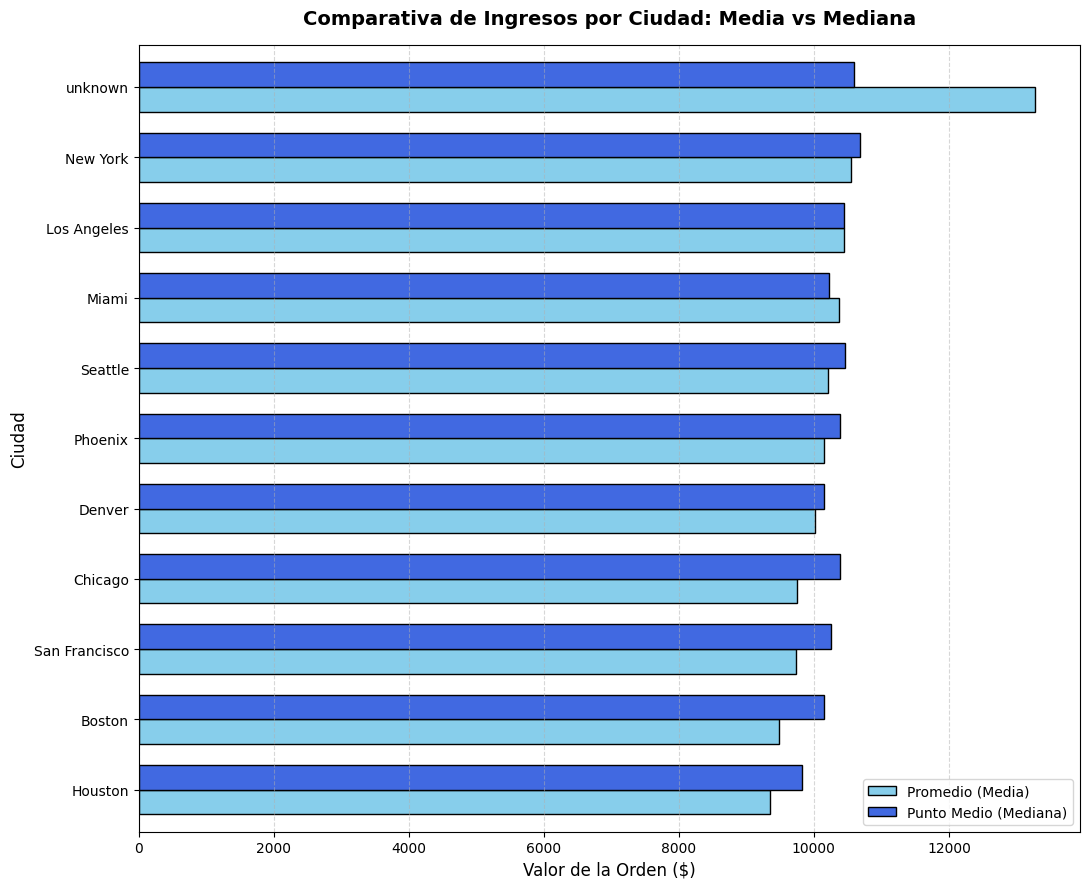

In [23]:
# Unimos los datos de las ciudades para comparar
df_city = pd.DataFrame(
    {"Media": revenue_city_mean, "Mediana": revenue_city_med}
).sort_values(by="Media", ascending=True)  # Ascendente para que la mayor quede arriba en el gráfico horizontal

# Graficar barras horizontales agrupadas
ax = df_city.plot(
    kind="barh",
    figsize=(11, 9),
    color=["skyblue", "royalblue"],
    edgecolor="black",
    width=0.7,
)

# Personalización estética del gráfico
plt.title(
    "Comparativa de Ingresos por Ciudad: Media vs Mediana",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Valor de la Orden ($)", fontsize=12)
plt.ylabel("Ciudad", fontsize=12)

# Grid para que las líneas punteadas sean verticales
plt.grid(axis="x", linestyle="--", alpha=0.5)

# leyenda para identificar los colores
plt.legend(["Promedio (Media)", "Punto Medio (Mediana)"], loc="lower right")

plt.tight_layout()
plt.show()

In [24]:
# Ingresos por categoria de productos 

reve_prod_cat_mean =  df_final.groupby(df_final['product_category'])['order_value'].mean().sort_values(ascending= False)
reve_prod_cat_med =  df_final.groupby(df_final['product_category'])['order_value'].median().sort_values(ascending= False)

print("===Ingresos promedio por categoría de producto:===")
print(reve_prod_cat_mean)
print("\n===Mediana de ingresos por categoría de producto:===")
print( reve_prod_cat_med ) 

===Ingresos promedio por categoría de producto:===
product_category
Electronics    18260.601361
Sports         10365.264957
Home           10214.101620
Fashion         8745.139378
Toys            7903.381818
Beauty          7889.285714
unknown         7737.160000
Grocery         6943.137427
Name: order_value, dtype: float64

===Mediana de ingresos por categoría de producto:===
product_category
Electronics    12484.0
Home           10750.0
Sports         10569.5
Toys            8228.0
Fashion         8115.0
Beauty          7047.0
Grocery         4131.0
unknown         3016.0
Name: order_value, dtype: float64


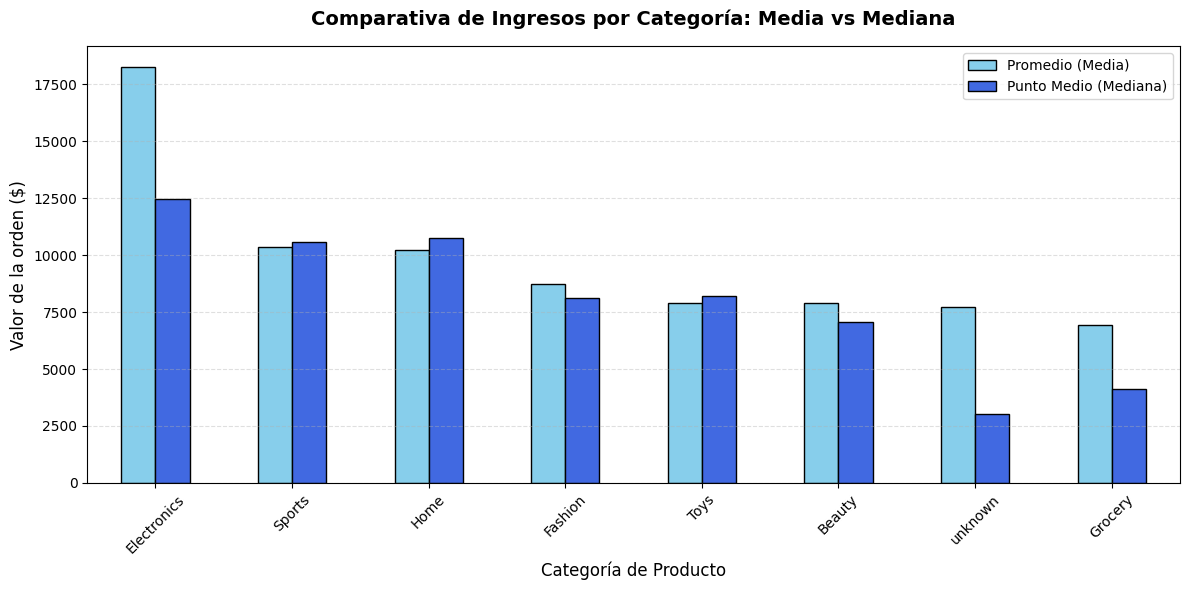

In [25]:
# Visualización de ingresos por categoria de productos 
# Nuevo Dataframe con los calculos media y mediana
df_cat = pd.DataFrame(
    {
        "Media": reve_prod_cat_mean,
        "Mediana": reve_prod_cat_med,
    }
).sort_values(by="Media", ascending=False)

# Graficar barras agrupadas
ax = df_cat.plot(
    kind="bar", figsize=(12, 6), color=["skyblue", "royalblue"], edgecolor="black"
)

plt.title(
    "Comparativa de Ingresos por Categoría: Media vs Mediana",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Categoría de Producto", fontsize=12)
plt.ylabel("Valor de la orden ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(["Promedio (Media)", "Punto Medio (Mediana)"])

plt.tight_layout()
plt.show()

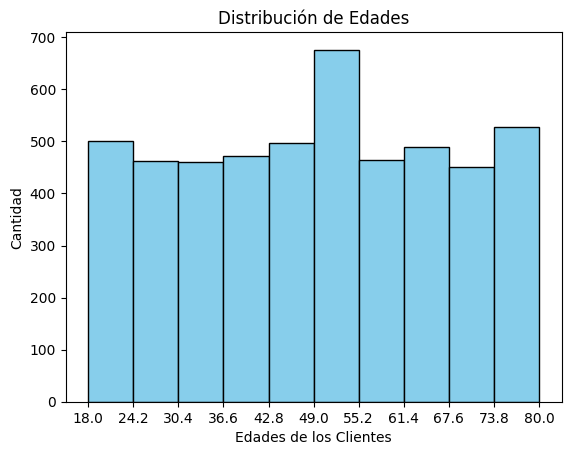

In [26]:
# Graficar histograma (Distribución de edad de los clientes)
counts, bin_edges, _ = plt.hist( df_final['customer_age'], bins= 10, color= 'skyblue', edgecolor= 'black')

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)

# Etiquetas y título del gráfico
plt.xlabel("Edades de los Clientes")
plt.ylabel("Cantidad")
plt.title("Distribución de Edades")
plt.show()

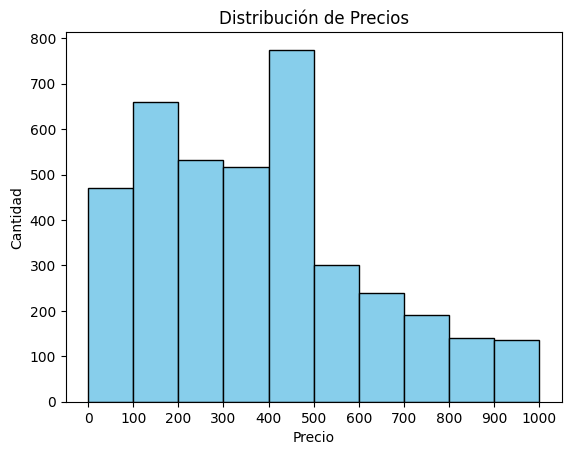

In [27]:
# Graficar histograma
counts, bin_edges, _ = plt.hist( df_final['price'], bins=10, range=(0, 1000), color= 'skyblue', edgecolor= 'black')

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)

# Etiquetas y título del gráfico
plt.xlabel("Precio")
plt.ylabel("Cantidad")
plt.title("Distribución de Precios")
plt.show()

# Detección de outliers


In [29]:
# OUTLIERS CON IQR EN ORDER VALUE
# calcular Q1, Q3 e IQR
Q1 = df_final['order_value'].quantile(0.25)
Q3 = df_final['order_value'].quantile(0.75)
IQR = Q3 - Q1

# calcular límite inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Mostrar resultados
print('Primer cuartil: ', Q1)
print('Tercer cuartil: ', Q3)
print('IQR: ', IQR)

print("\nRegistros abajo del límite inferior")
print(df_final[ df_final['order_value'] < limite_inferior] )

print("\nRegistros arriba del límite superior")
print(df_final[ df_final['order_value'] > limite_superior] )


Primer cuartil:  3094.0
Tercer cuartil:  13160.5
IQR:  10066.5

Registros abajo del límite inferior
Empty DataFrame
Columns: [order_id, order_date, customer_id, product_category, price, quantity, order_value, payment_method, city, state, customer_age]
Index: []

Registros arriba del límite superior
      order_id order_date  customer_id product_category  price  quantity  \
8            9 2024-03-14         2925           Beauty     55         1   
123        124 2024-06-21         1389      Electronics   1947         0   
155        156 2024-08-30         2901          Grocery     36         1   
199        200 2024-12-18         2919          Fashion   5174         0   
265        266 2024-07-31         1905      Electronics   2897         0   
...        ...        ...          ...              ...    ...       ...   
4934      4935 2024-05-19         1502      Electronics   4282         0   
4936      4937 2024-12-17         1907             Home   1522         0   
4942      4943 2

In [30]:
# OUTLIERS CON Z SCORE EN ORDER VALUE
# Cálculo del Z-score
mean = df_final['order_value'].mean()

#cálculo de la desviación estándar
std = df_final['order_value'].std()

#Crea el z score
df_final['z'] = (df_final['order_value']- mean) / std

#Calcula los valores extremos
print(df_final[df_final['z'].abs() > 3])


      order_id order_date  customer_id product_category  price  quantity  \
293        294 2024-05-01         2149      Electronics   3336         0   
369        370 2024-10-09         2784      Electronics   5973         0   
375        376 2024-02-04         2285      Electronics   4782         0   
391        392 2024-03-06         2981      Electronics   2463         0   
397        398 2024-03-12         2024      Electronics   4893         0   
...        ...        ...          ...              ...    ...       ...   
4698      4699 2024-04-20         2059      Electronics   5227         0   
4732      4733 2024-10-06         2685           Sports   3394         0   
4908      4909 2024-10-19         1119      Electronics   3927         0   
4921      4922 2024-11-15         1621           Sports   2765         0   
4942      4943 2024-11-02         1979      Electronics   6478         0   

      order_value payment_method      city    state  customer_age         z  
293      

In [31]:
# COMPARACIÓN DE IQR Y Z-SCORE EN 'price'
Q1 = df_final['price'].quantile(0.25)
Q3 = df_final['price'].quantile(0.75)
IQR = Q3 - Q1

# calcular límite inferior y superior
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# ----- Z-score -----
# calcular media, desviación estándar y z-score
mean = df_final['price'].mean()
std = df_final['price'].std()
df_final['z'] = (df_final['price']- mean) /std

# ----- Mostrar resultados -----
print('Outliers usando IQR:')
print( df_final[ (df_final['price'] < lower) | (df_final['price'] > upper) ] )

print('\nOutliers usando Z-Score:')
print( df_final[df_final['z'].abs() > 3] )

Outliers usando IQR:
      order_id order_date  customer_id product_category  price  quantity  \
64          65 2024-05-30         1651           Sports   2106         5   
67          68 2024-05-15         2385             Home   5181         0   
95          96 2024-04-15         2991           Sports   1940         0   
123        124 2024-06-21         1389      Electronics   1947         0   
138        139 2024-05-07         2274      Electronics   2437         6   
...        ...        ...          ...              ...    ...       ...   
4955      4956 2024-03-11         2230      Electronics   3824         0   
4974      4975 2024-10-20         2627      Electronics   1985         6   
4984      4985 2024-03-11         2509           Sports   1911         0   
4990      4991 2024-08-25         2569           Sports   2856         5   
4997      4998 2024-10-26         2838      Electronics   2699         4   

      order_value payment_method         city    state  customer_a

In [41]:
## Error en la captura de la columna 'qiuantity' se eliminaron filas con error en la fecha, asi como valores en 0 de esta columna
print("Total de filas con 0 en 'quantity':", (df_final['quantity']== 0).sum())

Total de filas con 0 en 'quantity': 2966
